# Country Clustering: Which Countries Need Aid the Most?

## Business problem
HELP International is a humanitarian NGO that has raised roughly **$10 million**. The CEO has to decide how to spend it where it will matter most, which means working out which countries are in the most urgent need of aid.

**Goal:** group 167 countries by their socio-economic and health indicators, then identify the group that should receive funding first.

## Dataset
Each row is one country. The columns are:

| Column | Meaning |
|---|---|
| `child_mort` | Deaths of children under 5 per 1,000 live births |
| `exports` | Exports of goods and services, as % of GDP per capita |
| `health` | Total health spending, as % of GDP per capita |
| `imports` | Imports of goods and services, as % of GDP per capita |
| `income` | Net income per person |
| `inflation` | Annual growth rate of total GDP (inflation measure) |
| `life_expec` | Average life expectancy of a newborn, in years |
| `total_fer` | Children per woman if current fertility rates stay the same |
| `gdpp` | GDP per capita |

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("29-country_data.csv")

## 1. Exploratory Data Analysis
Before modelling, I check the shape of the data, the distribution of each feature, how features relate to each other, and whether there are outliers.

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.shape

(167, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
import math

def plot_all_histograms(df, title_prefix = ""):
    num_cols = df.select_dtypes(include = [np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols )

    plt.figure(figsize =(5 * n_cols, 4 * n_rows))

    for i ,col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col],  kde = True,bins = 30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

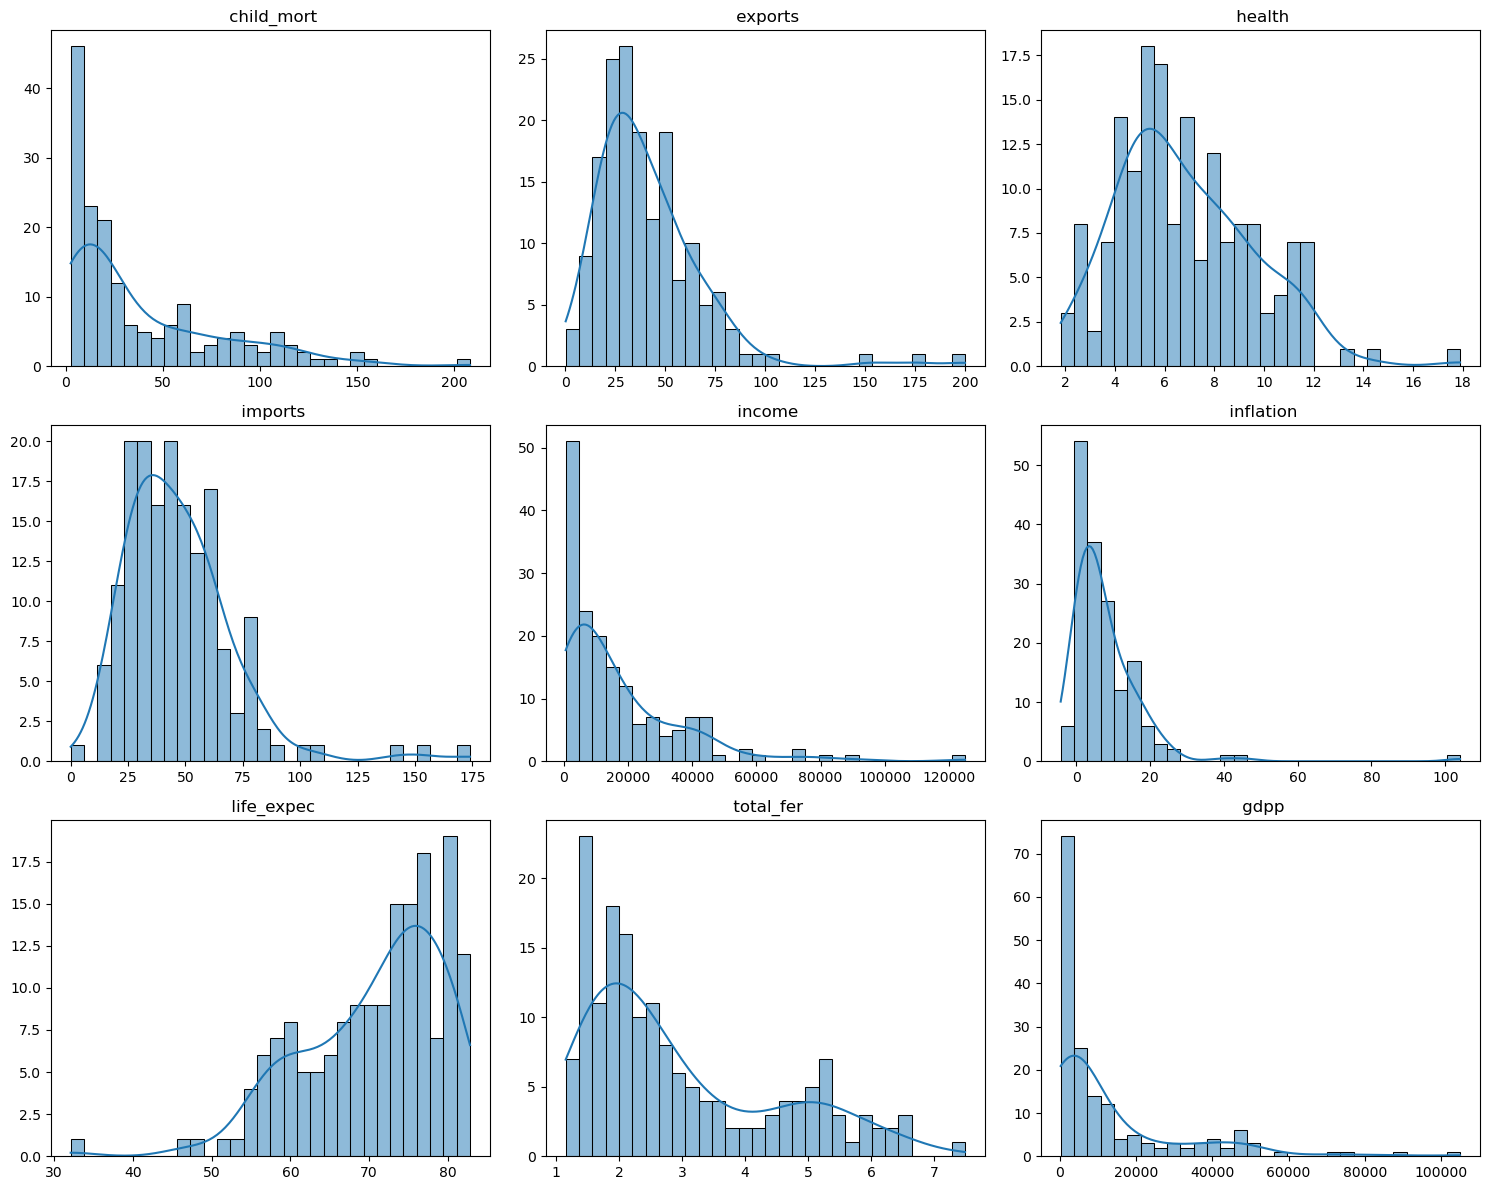

In [8]:
plot_all_histograms(df)

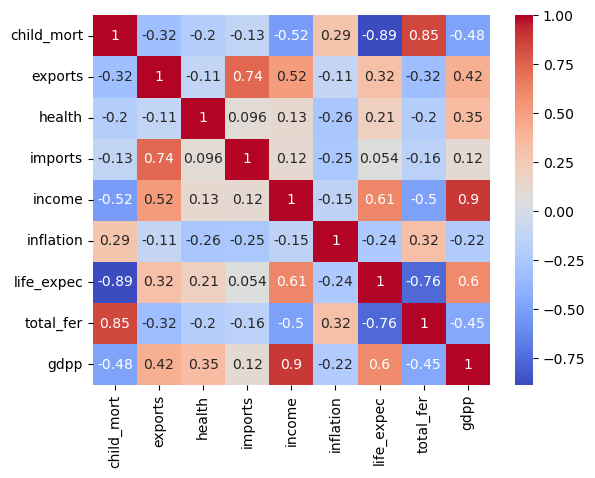

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap="coolwarm")
plt.show()

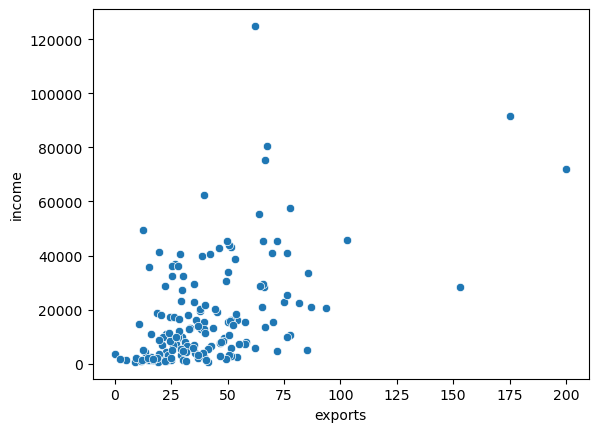

In [10]:
sns.scatterplot(data = df, x = "exports", y = "income")
plt.show()

In [11]:
import math

def plot_all_box(df, title_prefix = ""):
    num_cols = df.select_dtypes(include = [np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols )

    plt.figure(figsize =(5 * n_cols, 4 * n_rows))

    for i ,col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(df[col])
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

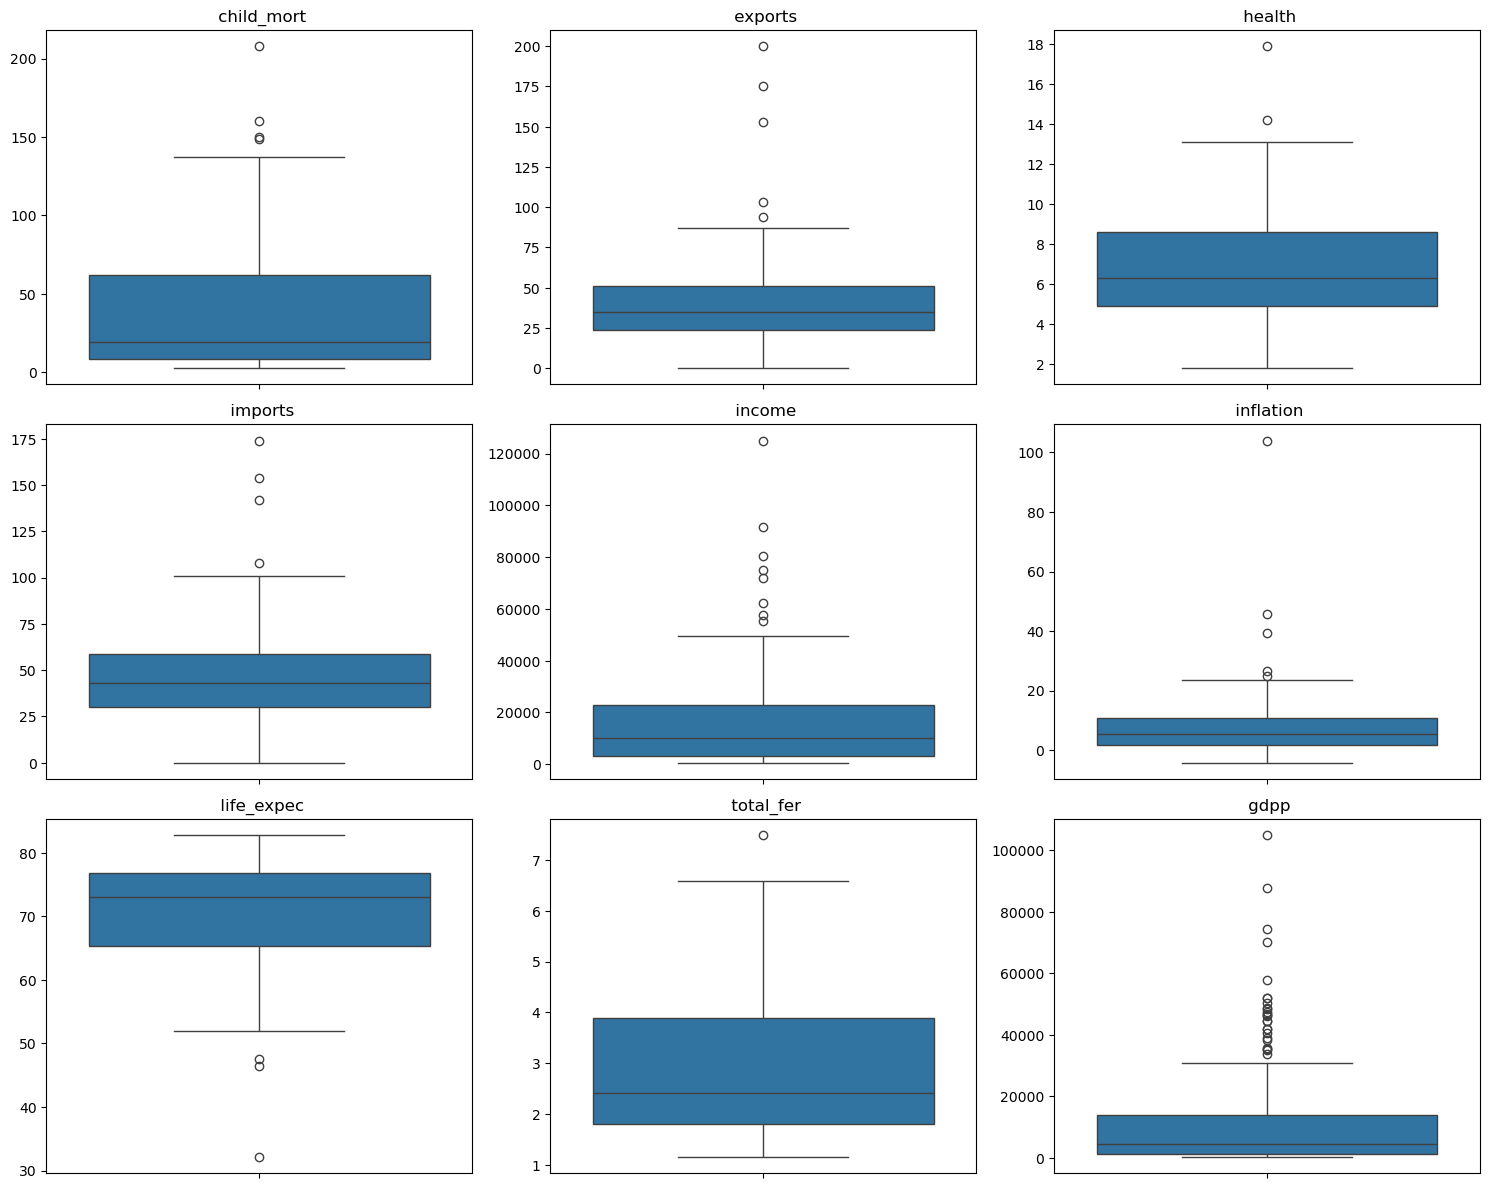

In [12]:
plot_all_box(df)

### Key observations
- **Strong skew:** `income`, `gdpp`, `child_mort`, `exports` and `imports` are right-skewed. A few very rich or very poor countries pull the tail out.
- **Correlated features:** `child_mort` is strongly negatively related to `life_expec` and positively related to `total_fer`, while `income` and `gdpp` move together. This redundancy is a good reason to use PCA later.
- **Outliers are real countries:** the extreme values come from genuine cases (small, trade-heavy or very wealthy economies, and very poor ones), not data errors, so I **transform** them rather than delete them.
- `inflation` contains **negative values**, which rules out a plain log transform.

## 2. Preprocessing
Clustering algorithms based on distance are sensitive to scale and skew, so I apply a **Yeo-Johnson power transform**. Unlike a log transform it works with negative values (such as `inflation`), and by default it also standardizes each feature to zero mean and unit variance, so no separate `StandardScaler` is needed.

In [13]:
df2 = df.drop("country", axis = 1)

In [14]:
from sklearn.preprocessing import PowerTransformer
pt_df = PowerTransformer(method = "yeo-johnson")
X = pt_df.fit_transform(df2)

In [15]:
X = pd.DataFrame(X , columns= ["child_mort","exports","health","imports","income","inflation","life_expec","total_fer","gdpp"])

In [16]:
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.266699,-1.671164,0.402266,0.064586,-1.368935,0.459416,-1.526455,1.544053,-1.462273
1,-0.220994,-0.380078,0.034400,0.226872,0.012538,-0.154659,0.621738,-0.992833,-0.121133
2,0.217834,0.105605,-0.991140,-0.610572,0.232275,1.059790,0.652698,0.313175,-0.063195
3,1.506186,0.943040,-1.727642,-0.026621,-0.408251,1.512843,-1.239045,1.623128,-0.219666
4,-0.637380,0.385850,-0.166030,0.641531,0.572583,-0.723442,0.699553,-0.368063,0.609228


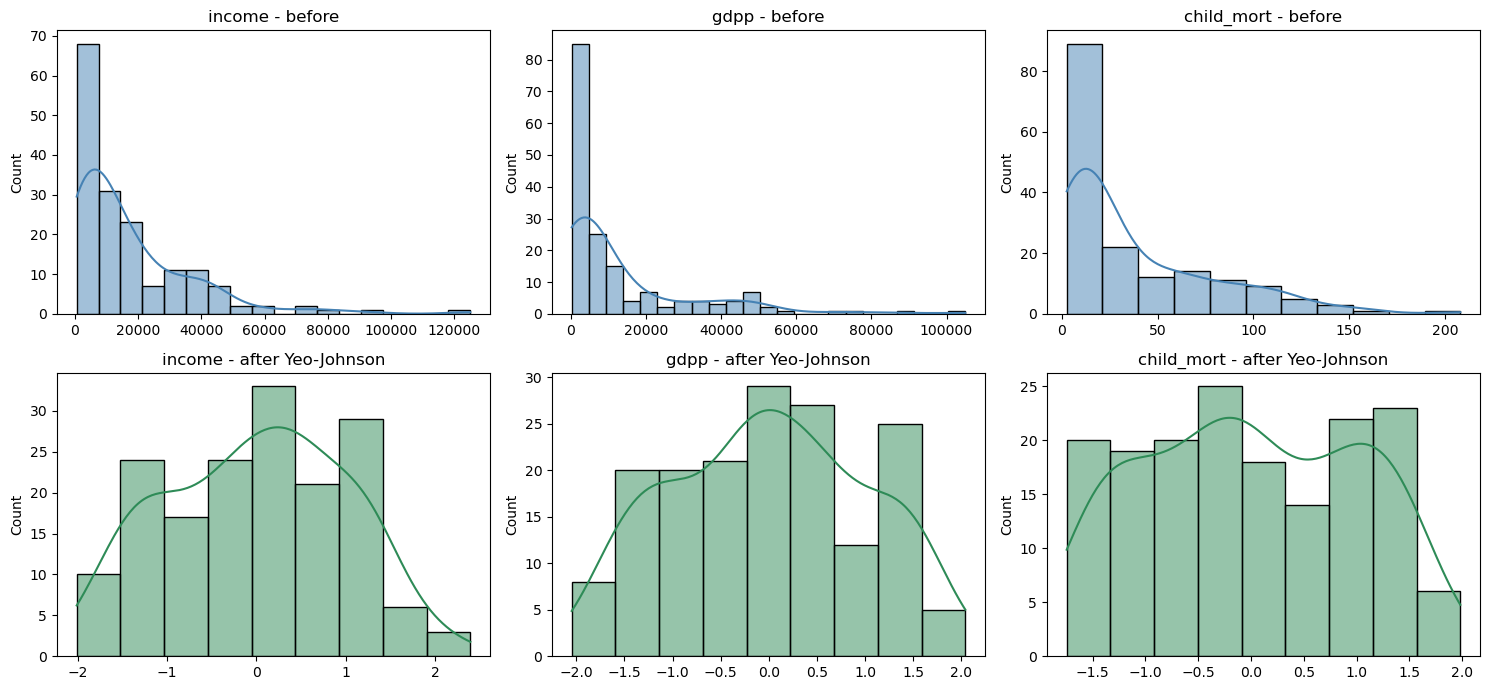

In [17]:
cols = ["income", "gdpp", "child_mort"]

fig, axes = plt.subplots(2, len(cols), figsize=(15, 7))
for j, col in enumerate(cols):
    sns.histplot(df2[col], kde=True, ax=axes[0, j], color="steelblue")
    axes[0, j].set_title(f"{col} - before")
    axes[0, j].set_xlabel("")

    sns.histplot(X[col], kde=True, ax=axes[1, j], color="seagreen")
    axes[1, j].set_title(f"{col} - after Yeo-Johnson")
    axes[1, j].set_xlabel("")

plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction (PCA)
Many features are strongly correlated, so PCA can compress them into a few independent components while keeping most of the information. This also removes noise and makes clustering more stable.

In [18]:
from sklearn.decomposition import PCA

In [19]:
pca = PCA()

In [20]:
pca_X = pd.DataFrame(pca.fit_transform(X))

In [21]:
pca.explained_variance_ratio_

array([0.54984157, 0.16624122, 0.13322683, 0.07142869, 0.03890754,
       0.02057842, 0.01179208, 0.00635443, 0.00162921])

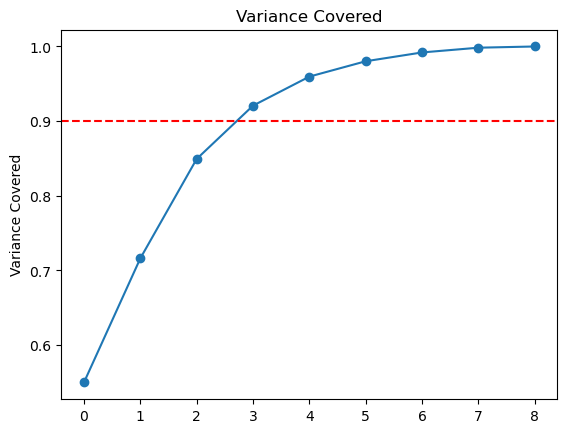

In [22]:
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.9, color="r", linestyle="--")
plt.ylabel("Variance Covered")
plt.title("Variance Covered")
plt.show()

In [23]:
pca = PCA(n_components=4)  
pca_X = pd.DataFrame(pca.fit_transform(X), columns=[f"PC{i+1}" for i in range(pca.n_components_)])

### Choosing the number of components
The first component alone explains about **55%** of the variance, and the first four together explain about **92%**, which passes the 90% threshold. I keep **4 components**.

`PC1` mostly behaves like a general *development level* axis: countries with high child mortality and fertility sit at one end, and countries with high income and life expectancy at the other.

In [24]:
pca_X

,PC1,PC2,PC3,PC4
0,3.407196,-0.080014,1.153852,0.285741
1,-0.662319,-0.209439,0.300697,-0.210357
2,0.305316,-0.666400,-1.430118,0.134497
3,2.415313,0.865053,-2.292952,0.324111
4,-1.501000,0.474915,-0.033024,-0.452832
...,...,...,...,...
162,1.142268,1.089312,0.041025,-0.535850
163,0.207726,-2.138191,-2.086254,1.487584
164,0.051239,1.679506,-0.252710,0.872473
165,2.239611,-0.311269,-0.895617,0.761871


## 4. K-Means Clustering
I run K-Means for k = 2 to 9 and compare the **elbow curve** (inertia) with the **silhouette score**.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
ks = range(2,10)
inertia, sil = [] , []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(pca_X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(pca_X, km.labels_))

In [27]:
inertia

[785.5420871529753,
 627.3938901720641,
 547.5915594225194,
 480.47820765113835,
 444.3085259233712,
 398.85916061466094,
 362.8610182738764,
 333.0248562800626]

In [28]:
sil

[0.36616823348035693,
 0.28424508754251543,
 0.26675251740065303,
 0.2530329734100392,
 0.2568788611183635,
 0.279490725073248,
 0.2565527939387329,
 0.2636120092509254]

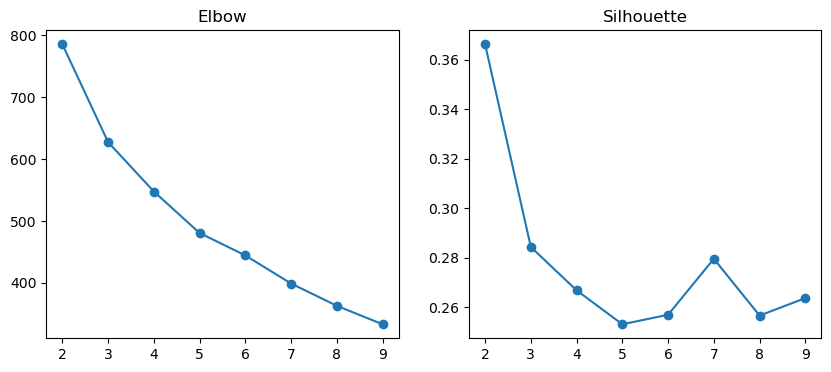

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, inertia, marker="o"); ax[0].set_title("Elbow")
ax[1].plot(ks, sil, marker="o");     ax[1].set_title("Silhouette")
plt.show()

### Choosing k
- The **silhouette score is highest at k = 2** (about 0.37), and there is no sharp elbow in the inertia curve.
- k = 2 only splits the world into "needs aid" and "does not", which is too coarse to prioritise funding.
- With **k = 3** the silhouette is lower (about 0.27) but the clusters are balanced and clearly interpretable as *low*, *middle* and *high* development, so I use **k = 3**.

In [30]:
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(pca_X)

In [31]:
df["cluster"] = km.labels_

In [32]:
df["cluster"].value_counts()

cluster
0    65
1    51
2    51
Name: count, dtype: int64

In [33]:
pca_X.insert(0, column="Country", value = df["country"])

In [34]:
order = df.groupby("cluster")["child_mort"].mean().sort_values(ascending=False).index
names = ["Budget Needed", "Medium Need", "No Budget Needed"]
label_map = dict(zip(order, names))

pca_X["cluster"] = pd.Series(km.labels_).map(label_map)

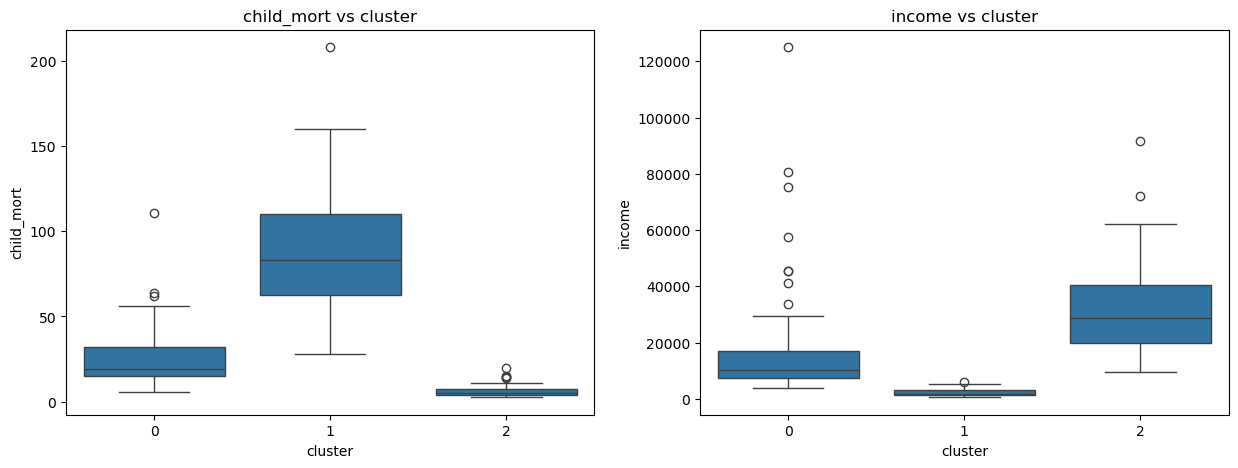

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(data = df, x = "cluster", y= "child_mort")
plt.title("child_mort vs cluster")

plt.subplot(1,2,2)
sns.boxplot(data = df, x = "cluster", y = "income")
plt.title("income vs cluster")

plt.show()

In [36]:
import plotly.express as px

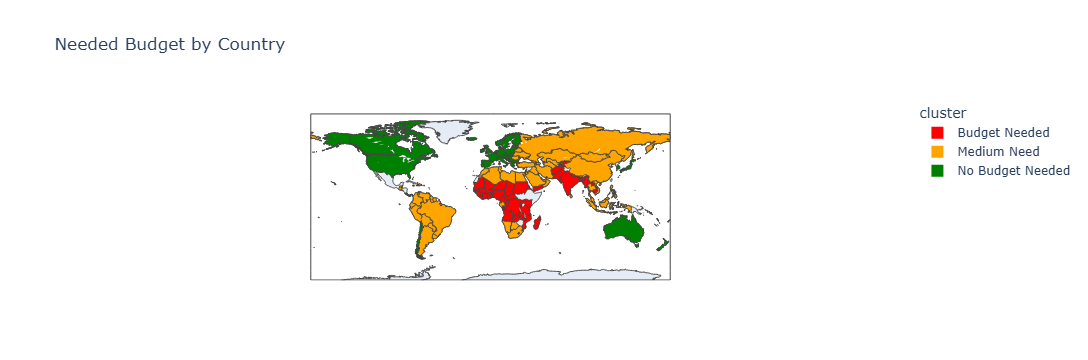

In [37]:
fig = px.choropleth(
    pca_X[["Country", "cluster"]],
    locationmode="country names",
    locations= "Country", 
    title = "Needed Budget by Country",
    color = pca_X["cluster"],
    color_discrete_map={
    "Budget Needed": "Red",
    "Medium Need": "Orange",
    "No Budget Needed": "Green"
    })
fig.update_geos(fitbounds = "locations", visible = True)
fig.show()

In [38]:
df["cluster_name"] = pd.Series(km.labels_).map(label_map)

In [39]:
df[df["cluster_name"] == "Budget Needed"].sort_values(
    ["child_mort", "gdpp"], ascending=[False, True]
)[["country", "child_mort", "income", "gdpp"]].head(10)

,country,child_mort,income,gdpp
66,Haiti,208.0,1500,662
132,Sierra Leone,160.0,1220,399
32,Chad,150.0,1930,897
31,Central African Republic,149.0,888,446
97,Mali,137.0,1870,708
113,Nigeria,130.0,5150,2330
112,Niger,123.0,814,348
3,Angola,119.0,5900,3530
37,"Congo, Dem. Rep.",116.0,609,334
25,Burkina Faso,116.0,1430,575


### Cluster results
The scatter plot shows how the three clusters separate in the first two principal components. The heatmap shows what each cluster looks like on the standardized features (red = above average, blue = below average). The bar chart lists the ten most urgent countries in the *Budget Needed* cluster.

In [40]:
fig = px.scatter(
    pca_X, x="PC1", y="PC2", color="cluster", hover_name="Country",
    color_discrete_map={"Budget Needed": "Red", "Medium Need": "Orange", "No Budget Needed": "Green"},
    category_orders={"cluster": ["Budget Needed", "Medium Need", "No Budget Needed"]},
    title="Countries in PC1-PC2 space")
fig.show()

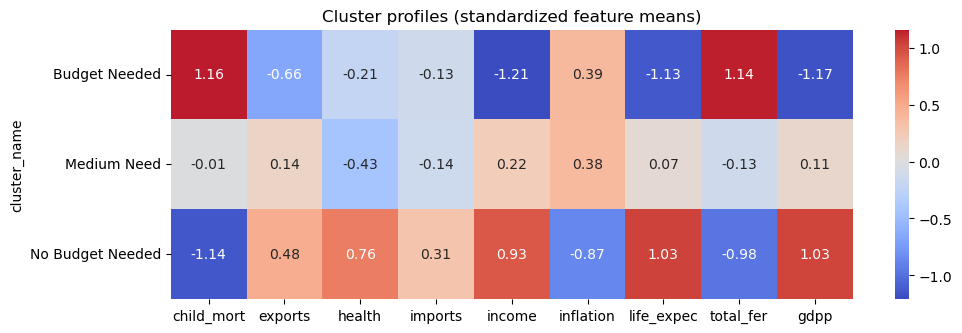

In [41]:
profile = X.groupby(df["cluster_name"]).mean().loc[["Budget Needed", "Medium Need", "No Budget Needed"]]
plt.figure(figsize=(11, 3.5))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster profiles (standardized feature means)")
plt.show()

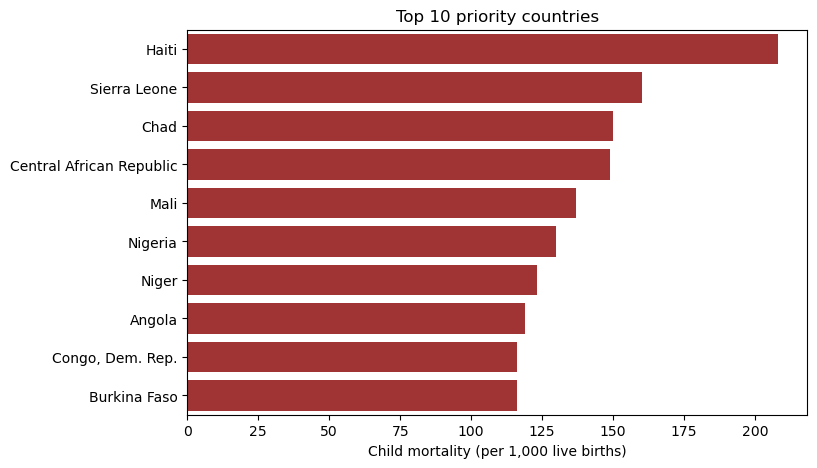

In [42]:
top10 = (df[df["cluster_name"] == "Budget Needed"]
         .sort_values(["child_mort", "gdpp"], ascending=[False, True]).head(10))
plt.figure(figsize=(8, 5))
sns.barplot(data=top10, y="country", x="child_mort", color="firebrick")
plt.xlabel("Child mortality (per 1,000 live births)")
plt.ylabel("")
plt.title("Top 10 priority countries")
plt.show()

In [43]:
pca_X

,Country,PC1,PC2,PC3,PC4,cluster
0,Afghanistan,3.407196,-0.080014,1.153852,0.285741,Budget Needed
1,Albania,-0.662319,-0.209439,0.300697,-0.210357,Medium Need
2,Algeria,0.305316,-0.666400,-1.430118,0.134497,Medium Need
3,Angola,2.415313,0.865053,-2.292952,0.324111,Budget Needed
4,Antigua and Barbuda,-1.501000,0.474915,-0.033024,-0.452832,No Budget Needed
...,...,...,...,...,...,...
162,Vanuatu,1.142268,1.089312,0.041025,-0.535850,Budget Needed
163,Venezuela,0.207726,-2.138191,-2.086254,1.487584,Medium Need
164,Vietnam,0.051239,1.679506,-0.252710,0.872473,Medium Need
165,Yemen,2.239611,-0.311269,-0.895617,0.761871,Budget Needed


In [44]:
new_df = pca_X.drop(["Country","cluster"], axis = 1)

In [45]:
new_df

,PC1,PC2,PC3,PC4
0,3.407196,-0.080014,1.153852,0.285741
1,-0.662319,-0.209439,0.300697,-0.210357
2,0.305316,-0.666400,-1.430118,0.134497
3,2.415313,0.865053,-2.292952,0.324111
4,-1.501000,0.474915,-0.033024,-0.452832
...,...,...,...,...
162,1.142268,1.089312,0.041025,-0.535850
163,0.207726,-2.138191,-2.086254,1.487584
164,0.051239,1.679506,-0.252710,0.872473
165,2.239611,-0.311269,-0.895617,0.761871


## 5. Density-based clustering (DBSCAN and HDBSCAN)
Density-based methods find clusters of any shape and mark sparse points as noise. Noise points (`-1`) are left out of the silhouette score, and each row also reports `n_noise`: a setting that leaves many countries unassigned is not useful here, because every country needs a cluster.

In [46]:
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_sample_values = [4,5,6]

In [47]:
from sklearn.cluster import DBSCAN,HDBSCAN
from sklearn.metrics import silhouette_score
results = []

for eps in eps_values:
    for min_samples in min_sample_values:
        db = DBSCAN(eps = eps,min_samples = min_samples).fit(new_df)
        labels = db.labels_

        mask = labels != -1                      
        n_clusters = len(set(labels[mask]))

        if n_clusters < 2:
            continue
            
        silhouette = silhouette_score(new_df, labels)
        results.append(
            {
                "eps":eps,
                "min_samples": min_samples,
                "Silhouette": silhouette,
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "Silhouette", ascending = False)

In [48]:
results_df

,eps,min_samples,Silhouette,n_clusters
0,0.5,4,-0.186911,2
1,0.6,4,-0.299728,5


In [49]:
min_cluster_size = [3,4,5]
min_samples = [None, 3,5,7]

In [50]:
results = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size = min_cluster,min_samples = min_sample).fit(new_df)
        labels = hdb.labels_

        mask = labels != -1                      
        n_clusters = len(set(labels[mask]))

        if n_clusters < 2:
            continue
        silhouette = silhouette_score(new_df, labels)
        results.append(
            {"min_cluster_size": min_cluster,
            "min_samples": min_sample,
            "Silhouette": silhouette,
            "n_clusters: ": len(set(labels)) - (1 if -1 in labels else 0 )}
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "Silhouette", ascending = False)

In [51]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters:
9,5,3.0,0.163640,2
6,4,5.0,0.075289,2
8,5,NaN,0.075289,2
10,5,5.0,0.075289,2
3,3,7.0,0.054896,2
7,4,7.0,0.054896,2
11,5,7.0,0.054896,2
4,4,NaN,-0.031073,3
5,4,3.0,-0.038128,4
2,3,5.0,-0.059576,3


In [52]:
new_df

,PC1,PC2,PC3,PC4
0,3.407196,-0.080014,1.153852,0.285741
1,-0.662319,-0.209439,0.300697,-0.210357
2,0.305316,-0.666400,-1.430118,0.134497
3,2.415313,0.865053,-2.292952,0.324111
4,-1.501000,0.474915,-0.033024,-0.452832
...,...,...,...,...
162,1.142268,1.089312,0.041025,-0.535850
163,0.207726,-2.138191,-2.086254,1.487584
164,0.051239,1.679506,-0.252710,0.872473
165,2.239611,-0.311269,-0.895617,0.761871


## 6. Hierarchical clustering
Ward linkage builds a dendrogram, and I compare Agglomerative clustering for 2 to 9 clusters with the silhouette score.

In [53]:
import scipy.cluster.hierarchy as sch

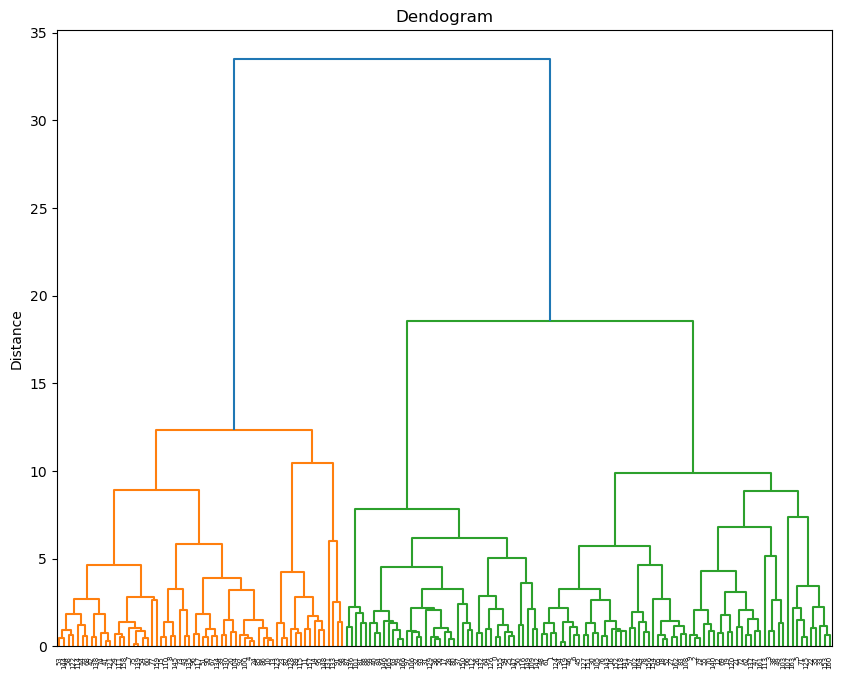

In [54]:
plt.figure(1, figsize = (10,8))
dendogram = sch.dendrogram(sch.linkage(new_df,method ="ward"))
plt.title("Dendogram")
plt.ylabel("Distance")
plt.show()

In [55]:
from sklearn.cluster import AgglomerativeClustering

In [56]:
n_clusters = [2,3,4,5,6,7,8,9] 

In [57]:
results = []

for n in n_clusters:
    agg =AgglomerativeClustering(n_clusters=n)
    y_pred = agg.fit_predict(new_df)
    silhouette = silhouette_score(new_df, y_pred)

    results.append(
        {
            "n_clusters": n,
            "silhouette" : silhouette
        }
    )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "silhouette", ascending = False)

In [58]:
results_df

,n_clusters,silhouette
0,2,0.345985
2,4,0.282076
3,5,0.273427
1,3,0.268545
4,6,0.255276
7,9,0.239904
6,8,0.239820
5,7,0.231596


In [59]:
agg = AgglomerativeClustering(n_clusters=2)
y_pred = agg.fit_predict(new_df)
print(silhouette_score(new_df, y_pred))

0.34598512418639


In [60]:
kmeans = KMeans(n_clusters=2,random_state=42, n_init = 10)
y_pred = kmeans.fit_predict(new_df)
print(silhouette_score(new_df,y_pred))

0.36616823348035693


## 7. Model comparison
All four models are scored on the same 4 PCA components. Higher Silhouette and Calinski-Harabasz are better, lower Davies-Bouldin is better.

In [61]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

models = {
    "K-Means (k=2)": KMeans(n_clusters=2, n_init=10, random_state=42),
    "K-Means (k=3)": KMeans(n_clusters=3, n_init=10, random_state=42),
    "Agglomerative (k=2)": AgglomerativeClustering(n_clusters=2),
    "Agglomerative (k=3)": AgglomerativeClustering(n_clusters=3),
}
rows = []
for name, model in models.items():
    lab = model.fit_predict(new_df)
    rows.append({"Model": name,
                 "Silhouette": silhouette_score(new_df, lab),
                 "Davies-Bouldin (lower is better)": davies_bouldin_score(new_df, lab),
                 "Calinski-Harabasz": calinski_harabasz_score(new_df, lab)})
pd.DataFrame(rows).round(3)

,Model,Silhouette,Davies-Bouldin (lower is better),Calinski-Harabasz
0,K-Means (k=2),0.366,1.037,125.676
1,K-Means (k=3),0.284,1.231,98.871
2,Agglomerative (k=2),0.346,1.066,112.182
3,Agglomerative (k=3),0.269,1.273,92.170


## 8. Conclusion
I compared K-Means, Agglomerative clustering, DBSCAN and HDBSCAN. The density-based methods did not fit this data well: countries lie on a continuous development spectrum with no clear low-density gaps, so they either labelled many countries as noise or scored lower than K-Means and Agglomerative clustering.

**Final model:** K-Means with k = 3 on 4 PCA components. It splits the 167 countries into three balanced, interpretable groups:
- **Budget Needed (51 countries):** very high child mortality (about 87 per 1,000), low income (about 2,300) and GDP per capita (about 1,070), low life expectancy and high fertility.
- **Medium Need (65 countries):** middle values on all indicators.
- **No Budget Needed (51 countries):** low child mortality, high income and life expectancy.

**Recommendation:** HELP International should focus its funding on the *Budget Needed* group, starting with the countries that have the highest child mortality and lowest GDP per capita (for example Haiti, Sierra Leone, Chad, Central African Republic and Mali).

**Limitations:** silhouette scores are modest (about 0.27 for k = 3), so cluster boundaries are fuzzy, and the analysis uses only the nine indicators in the dataset (no political or conflict data).